# Introduction

In this workshop, we will consider the online advertising market *from the perspective of the advertisers*. In particular, you have been hired by Ben, the CEO of a legacy high-street fashion retailer in the UK. In the past few years, the retail sector has been profundly disrupted by online purchasing behaviors. In-store sales have sharply declined by 4% per year, while online sales are growing at a steady 10% per year. While Ben's business has been relatively resilient across his network of stores, the push toward "online retailing" is irresistible. Ben has made sizeable investments to build a modern online retail platforms. That said, the traffic (i.e., volume of visitors) to his website remains limited, and the online business is still fledgling. 

You first mission is to operate a large-scale online advertising campaign to attract more users to the platform and bring awareness around the online presence of Ben's fashion brand. Ben wants to spend at least £1M during one month, and attract at least 200K new visitors. Ben vaguely remembers from his EMBA at LBS that *optimization* plays an important role in online advertising. However, the online advertising eco-system is complex and difficult to navigate. 

### Online advertising eco-system

The online advertising eco-system has two main intermediaries.

<img src="advertising.png" width="500">

- *Online ad exchanges*: The ad exchanges run auctions to allocate advertising space to advertisers. The ad exchange is responsible for the auction mechanism (who gets what? at which price?). The most popular online ad exchanges are Facebook and Google Adwords. 
- *Demand-side platforms (DSP)*: DSPs manage the client side. DSPs are responsible for the operational execution of online advertising campaigns on behalf of the advertisers. They decide whether they should participate in each eligible auction and how much to bid.

Ben has  hired a DSP to run a campaign on Google Adwords. However, there are are number of parameters that need to be determined. You will need to answer the following basic questions:
- *Which keywords should you advertise to?*
- *How should you allocate your budget across keywords?*
- *What total budget should be endowed to the advertising campaign?*

*Terminology*: When the DSP wins an auction, the ad is displayed to the corresponding user. This is known as an *impression*. The main metric tracked by the advertiser is the *cost-per-click* (CPC). This notion corresponds to the rate of budget spent per click. The CPC for a given keyword $k$ is computed as follows:

$$ CPC(k) = \frac{{\rm amount\ spent\ on\ keyword\ }{ k}}{{\rm number\ of\ clicks\ on\ keyword\ }{ k}} $$

### Your assignment

*Historical data*: The DSP platform has given you access to historical data to guide your decisions. The data has been generated by  advertising campaigns run by the DSP for very similar clients (namely, retailers in the UK). Specifically, each observation is a combination of a keyword and a weekly spend level, as well as the resulting number of clicks. Each user's click is redirected to the e-commerce website, so that each click roughly corresponds to a new visitor.

*Approach*: Your goal is to build a model to decide on how much should be spent on each keyword, given a prospective budget of £1M. The historical data will be utilized to construct a model that predicts the cost-per-click. Next, the budget allocation is determined via a linear optimization model.
- *The code cells are partially filled. You need to complete and execute the code in each cell.*
- *Make sure to answer all the questions along the way.*

**Submission**: Your submission should include the following:
- *Notebook:* An html file along with a .ipynb file containing all answers to the questions and completed workshop code (Ask for help to your LLM of choice or write formulas manually and upload them into a .doc file if needed).
- *Executive summary:* A 1 pager report summarizing all your findings (at least 11 pt font, 1 inch margin, pdf/doc format). This report should take the form of an executive summary that combines elements of your analysis and business recommendations. Supporting evidence can be provided in an appendix, or by referencing the questions of the workshop. The report will be evaluated along 3 dimensions: clarity, scientific validity, practical relevance.

# Q1. Explore the data (10 pt)

The DSP platform has shared data on five potentially keywords, that have been carefully selected by Ben and his chief marketing officer. For each keyword, the DSP has identified UK retailers amongst its previous clients, having the same product positioning as Ben's. These retailers have spent various amounts on each keyword in the past quarter, ranging from thousands to millions of pounds per month. The DSP provides the exact amount spent in each campaign, as well as the number of generated clicks. The campaign data is reported on a monthly basis.

### Q1.1. Load the data

1. *Use the dataframe methods `.head()` and `.describe()` to visualize the table entries.*
- *Aggregate the data by keyword using the `.groupby()` construct.*

In [38]:
import pandas as pd

#Import warnings to ignore warnings
import warnings 
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv("data_keywords.csv").set_index("ID")

In [39]:
# Insert your code below
df.head()
# df.dtypes
# df.shape

,keyword,budget,clicks
ID,,,
1,"""retail UK""",10022.696190,3021
2,"""retail UK""",18434.623580,5570
3,"""retail UK""",11439.698520,3498
4,"""retail UK""",2985.138079,995
5,"""retail UK""",16968.520950,5121


In [40]:
df.describe()

,budget,clicks
count,145.000000,145.000000
mean,144266.904428,14507.482759
std,267773.129547,28965.202034
min,555.151409,305.000000
25%,8422.761074,2550.000000
50%,17608.171090,4994.000000
75%,76357.516670,9708.000000
max,998166.121400,143466.000000


In [41]:
df['keyword'].value_counts()

keyword
"retail UK"           29
"free shipping UK"    29
"cardigan"            29
"dua lipa gloves"     29
"spotted dress "      29
Name: count, dtype: int64

### Q1.2. Define the cost-per-click (CPC) as a new column of the dataframe `df`

In [42]:
# Uncomment and fill the code below

df['CPC'] = df['budget'] / df['clicks']
df.reset_index(inplace=True)
df.head()

,ID,keyword,budget,clicks,CPC
0,1,"""retail UK""",10022.696190,3021,3.317675
1,2,"""retail UK""",18434.623580,5570,3.309627
2,3,"""retail UK""",11439.698520,3498,3.270354
3,4,"""retail UK""",2985.138079,995,3.000139
4,5,"""retail UK""",16968.520950,5121,3.313517


Below, we provide code to a boxplot diagram (using `sns.boxplot()`) to display the distribution of the cost-per-click CPC for each keyword.

*Note: In data science practice, it is preferable to include all the package/module dependencies at the beginning of your notebook or script. That said, for greater clarity in this workshop, we introduce them in a gradual manner.*


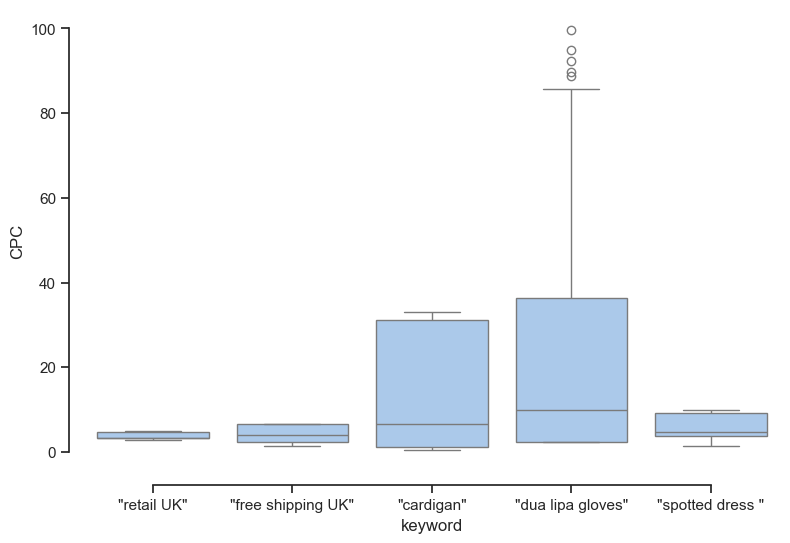

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# set figurfe size and style 
plt.subplots(figsize=(9,6))
sns.set(style="ticks", palette="pastel")

# Draw a boxplot to show CPC per keyword
sns.boxplot(x="keyword", y="CPC",
            data=df)             
# The next command is used to adj
sns.despine(offset=10, trim=True)

### Q1.3. Which keyword has the best CPC? Which keyword has the worst CPC? What hypotheses might explain the level of variability of CPC within the same keyword?

*Insert your answer below:*

The lower the CPC, the better it is i.e. the more clicks you get at a lower cost. 'retail UK' has the best CPC with the max CPC  ~£5. 'dua lipa gloves' has the worst CPC with upper range ~ £90 per click, with outliers even greater than that. 

The likelihood of clicking on a keyword can be measured with the CTR metric: #clicks / #impressions. The CTR of a keyword depends on seasonality, timeliness and relevance to a given DSP client. CPC, cost (£) / #clicks, of a keyword therefore varies in response to the CTR of a keyword for a given client at a given time. This explains the great variability in CPC among clients with large budgets:
- E.g. 'dua lipa gloves' CPC could be *~£20 for a brand like Zara*, who emulate and sell the singer's stage accessory **within a week of the singer's performance in March**, which suits the retailer's USP of being the quickest to be the trendiest.
- E.g. 'dua lipa gloves' CPC could be *~£40 for a brand like M&S*, who would emulate and sell the accessory **in time for it's summer collection launch in June**, long after the trend's popularity and in an attempt to attract to grow its young, female target segment. 


A finer visualization is proposed below. *Execute the code in the next cell.*

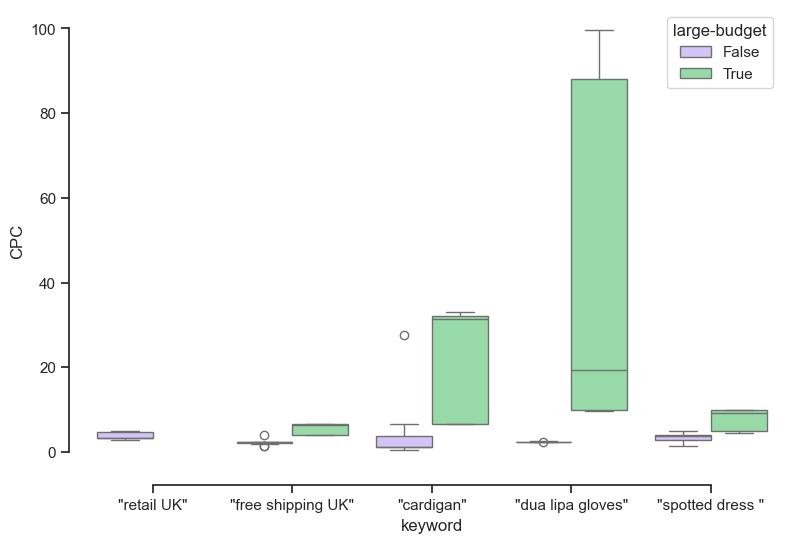

In [44]:
df['large-budget'] = df['budget']>=20000
plt.subplots(figsize=(9,6))
sns.set(style="ticks", palette="pastel")
sns.boxplot(x="keyword", y="CPC",hue="large-budget", palette=["m", "g"],
            data=df)             
sns.despine(offset=10, trim=True)

### Q1.4. How do you interpret the boxplot above?

*Insert your answer below:*

The box plot shows the range of CPCs for keywords depending on whether the budget is large or not. 

It shows that 'retail UK' was only selected by DSP clients without large budgets, likely due to its pertinence and cost-effectiveness.

Across the remaining keywords, there is large variability in CPC for clients with larger budgets. This would be due to aucion pressure from competitors with similar budgets, as well as diminishing returns on the impressions that lead to clicks.

### Q1.5. Add one more visualization of your own. Describe what it shows and what your learn from it in 1-2 lines

*Insert answer here:*

The barplot shows the mean budget per keyword. This reflects the competition when bidding for keywords.

In [45]:
# Mean budget  per keyword

mean_df = df.groupby('keyword').mean('budget')

mean_df.reset_index(inplace=True)

mean_df.head()

,keyword,ID,budget,clicks,CPC,large-budget
0,"""cardigan""",73.0,143983.169227,8550.137931,12.994695,0.482759
1,"""dua lipa gloves""",102.0,166678.027221,4688.413793,28.173910,0.620690
2,"""free shipping UK""",44.0,230491.680782,37462.137931,4.084498,0.586207
3,"""retail UK""",15.0,11756.240907,3024.862069,3.886945,0.000000
4,"""spotted dress """,131.0,168425.404002,18811.862069,5.685519,0.551724


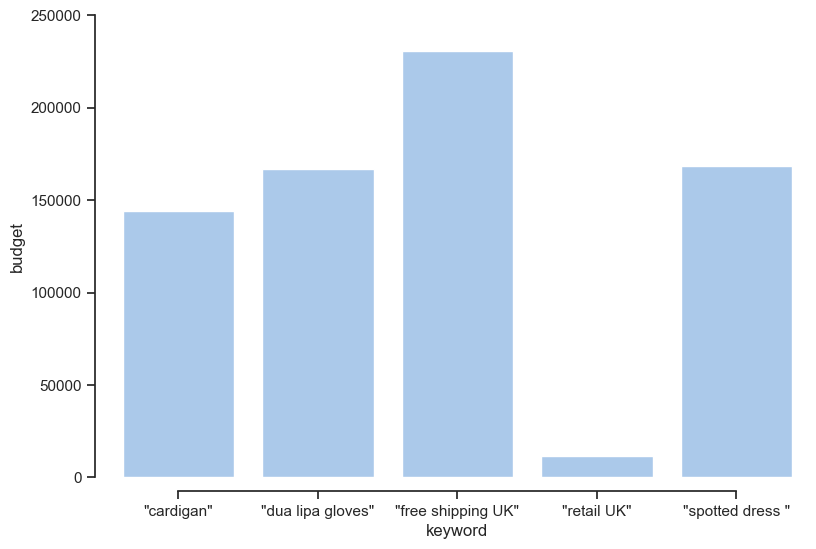

In [46]:
# Plot bar plot for mean df

#Set figure size and style
plt.subplots(figsize=(9,6))
plt.ylim(0, 250000)
sns.set(style="ticks", palette="pastel")

# Draw barplot
sns.barplot(
    data=mean_df,
    x="keyword", 
    y="budget"
    )

# adjust plot aesthetics
sns.despine(offset=10, trim=True)



# Q2. Build a linear regression model to predict CPC (5 pt)

As you know from Q1, the relationship between "clicks" and "budget spent" is not exactly linear. However, a linear model provides a good first-order approximation. You will begin by constructing a simple linear regression model to predict the relationship between clicks and cost *for each keyword*. To this end, you will fit a simple linear regression to predict the number of clicks (Y target variable) as a function of the budget spent (X dependent variable): 

$$ {\rm numberOfClicks}  = \alpha \cdot {\rm budgetSpent} $$

*Notes:* 
- Here, we assume that there is an intercept of zero; to obtain 0 click, you spend £0!
- Ultimately, we aim to construct a dictionary that maps each keyword to the corresponding CPC value.

### Q2.1. Provide detailed comments to explain each line of code below. What is the secret metric?

*Insert answer here:*

The 'secret metric' is the cost per click (CPC).

The regression slope estimates clicks per GBP; CPC is the inverse of this. This works because the intercept is forced to 0 i.e. when you have 0 clicks, you spend 0 GBP.

In [47]:
# Import libraries for linear regression
import numpy as np
from sklearn.linear_model import LinearRegression

# Create a list of keywords and an empty dictionary to store CPC values
keywords = df.keyword.drop_duplicates().tolist()
CPC = {}

# Fit linear regression models for each word and calculute CPC
for k in keywords:
    df_k = df[df["keyword"]==k]
    X = df_k.budget.values.reshape((df_k.shape[0],1))
    y = df_k.clicks.values 
    reg = LinearRegression(fit_intercept = False)
    reg.fit(X, y)
    CPC[k] = 1.0/reg.coef_[0]
    print("\n SecretMetric of keyword "+k+" is: £",1/reg.coef_[0]," per click")
    print("The R2 for the linear regression is:",reg.score(X,y))


 SecretMetric of keyword "retail UK" is: £ 3.9310780928924864  per click
The R2 for the linear regression is: 0.8437186291680528

 SecretMetric of keyword "free shipping UK" is: £ 6.60223809790213  per click
The R2 for the linear regression is: 0.9942768652156107

 SecretMetric of keyword "cardigan" is: £ 31.123341466626297  per click
The R2 for the linear regression is: 0.21794901967810065

 SecretMetric of keyword "dua lipa gloves" is: £ 82.3019858622777  per click
The R2 for the linear regression is: -1.183433985106006

 SecretMetric of keyword "spotted dress " is: £ 9.86900069149778  per click
The R2 for the linear regression is: 0.9912605411318857


In [48]:
keywords

['"retail UK"',
 '"free shipping UK"',
 '"cardigan"',
 '"dua lipa gloves"',
 '"spotted dress "']

### Q2.2. Does the predictive model agree with the observations made in Q1.3?

*Insert answer here:*

Yes the predictive model agrees with the observations made during EDA; 'retail' has the lowest CPC and 'dua lipa gloves' the highest.



# Q3. Find an optimal allocation strategy (15 pt)

Having computed the CPC associated with each keyword, you will now devise how the budget should be allocated across the keywords to maximize the number of clicks. The total budget available is of £1M. 

## Formulating the optimization 

### Q3.0. Formulate the optimal allocation strategy as a linear program

*Hint:* Formulas can be written manually and uploaded into a separate .doc file. Recall the linear program is determined with three components:
- Decision variables
- Constraints
- Objective function

*Insert your answer here*:


- Decision variable: budgets for each keyword $$ b_{k}$$ 
- Constraints:$$ \Sigma_{k}\cdot b_{k} ​≤ 1,000,000 $$ 
- Objective function:to maximise the number of clicks $$ \Sigma_{k}\frac{1}{CPC_{k}}\cdot b_{k} $$

The formula would therfore be:

$$max (\frac{1}{CPC_{k}}) = \frac{b_{r}}{CPC_{r}} + \frac{b_{fs}}{CPC_{fs}} + \frac{b_{c}}{CPC_{c}} + \frac{b_{dl}}{CPC_{dl}} + \frac{b_{sd}}{CPC_{sd}}$$



## Model creation

In [49]:
# The following lines of code import the gurobi package
import gurobipy as gp
from gurobipy import GRB,quicksum

### Q3.1. Create a GUROBI new model "m", named "allocation"

In [50]:
# Create optimisation model

m=gp.Model("allocation")

## Decision variables

In [51]:
allocation = m.addVars(keywords, lb = 0, name="allocation")
# Note: each decision variable is in £ unit

### Q3.2. Explain in detail what the code in the cell above is doing.

*Insert your answer here:*

The above code creates a dictionary of decision variables, with the first argument indicating that they depend on the keyword only.


## Constraint

### Q3.3. Is there a restriction on the `allocation` variables? Use the construct `m.addConstr()` to add the constraint to the model. 

*Insert your answer here:*


In [52]:
# Uncomment and fill the code below (keep the same structure):

# budget_constraint = m.addConstr( ,"budget_constraint")

budget_constraint = m.addConstr(
            sum(allocation[k] for k in keywords) <= 1000000, 
            f"budget_constraint"
            )

## Objective

### Q3.4. What is your objective? Which of the following options is correct?

*Insert your answer here:* Option 3 is correct


In [53]:
# Option 1
# m.setObjective(allocation.sum(), GRB.MAXIMIZE)

# Option 2
# m.setObjective(quicksum(CPC[k]*allocation[k] for k in keywords), GRB.MAXIMIZE)

# Option 3
m.setObjective(quicksum(1.0/CPC[k]*allocation[k] for k in keywords), GRB.MAXIMIZE)

## Solve

Congratulations! You have formulated and implemented the linear program. You can now optimize the allocation!

In [54]:
# Run the optimization and print the solution vector
def printSolution():
    if m.status == GRB.OPTIMAL:
        print('\nClicks: %g' % m.objVal)
        print('\nAllocation:')
        allocationx = m.getAttr('x', allocation)
        for k in keywords:            
                print('%s %g' % (k, allocationx[k]))
    else:
        print('No solution:', m.status)
        
m.optimize()
printSolution()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 5 columns and 5 nonzeros (Max)
Model fingerprint: 0xd02f5f23
Model has 5 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-02, 3e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+06, 1e+06]
Presolve removed 1 rows and 5 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.5438314e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.02 seconds (0.00 work units)
Optimal objective  2.543831428e+05

Clicks: 254383

Allocation:
"retail UK" 1e+06
"free shipping UK" 0
"cardigan" 0
"dua lipa gloves" 0
"spotted dress " 0


### Q3.5. How many keywords are selected in the bidding strategy? Why? Under which conditions is this strategy realistic?

*Insert your answer here:*

Only one keyword is selected. This is because 'retail UK' is the most cost-effective keyword thus generating the most clicks with the 1 million budget.

### Q3.6. Based on Q1.4, what aspect is not well-captured by the current CPC model?

*Insert your answer here:* 

The current CPC model does not capture the fact that the budget is large therefore we can satisfy the client's desired site traffic while diversifying the keywords to suit the niche of the customer base.

### Q3.7. Can you think about a different but equivalent formulation of the optimisation model? Outline decision variables, constraints and objective

Insert your answer here:

- Decision variables: clicks for each k
- Constraints: SUM(CPC x clicks) for each k =< 1000000
- Objective: maximise SUM (clicks for each k)



# Q4. Diversification (10 pt)

Ben (who is not well-versed in optimization) is puzzled by the outcome of the model. 

*Should we put all our eggs in one basket? I suggest to impose a constraint that at most £300,000 are invested on each single keyword. Hopefully, we will diversify our allocation strategy.*

### Q4.1 Add this constraint to the current model `m`

*Hint: Use the `m.addConstr()` or `m.addConstrs()` construct, and have a loop over the keywords*

*Execute the next cell to re-run the model and print the optimal allocation of budget*

In [55]:
# add diversification constraint

diversification_constrs=m.addConstrs((allocation[k] <= 300000 for k in keywords), name="diversification_constrs")

In [56]:
m.optimize()
printSolution()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 6 rows, 5 columns and 10 nonzeros (Max)
Model has 5 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-02, 3e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+05, 1e+06]
LP warm-start: use basis

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.5438314e+05   7.000000e+05   0.000000e+00      0s
       3    1.5536532e+05   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.553653168e+05

Clicks: 155365

Allocation:
"retail UK" 300000
"free shipping UK" 300000
"cardigan" 100000
"dua lipa gloves" 0
"spotted dress " 300000


### Q4.2. How do you explain the optimal amount spent on each keyword? Why is the keyword "dua lipa gloves"  left out?

*Insert your answer here:*

Budget is allocated sequentially to lowest CPC keyowords, until the diversification constraint is satisfied. Hence, 'retail UK' gets allocated the first 300000, followed by 'free shipping UK' then 'spotted dress'. The final 100000 is allocated to 'cardigan'.

### Q4.3. Do you find that Ben's modified model is satisfactory? Discuss qualitatively.

*Insert your answer here:*

I find Ben's model partially satisfactory. I think it may reduce his chances of meeting his 200k clicks benchmark, while potentially leading to higher conversion rates (user action after clicks on the ad e.g. making a purchase or subscribing to a newsletter).

On the one hand, by diversifying keywords, the outcome of the objective function is reduced. Reduced  visits to the client website may reduce cost-effectivness of the ad campaign. 

On the other hand, diversification reduces risks; if one keyword underperforms, then the others may compensate. Further, a broad range of keywords can create impressions on a broader audience, thus increasing impressions across the client's target segments. Though the objective function is reduced, the likelihood of converting clicks to user interactions leading to short-term and long-term revenue is greater; in this way, Ben's model of the optimised ad campaign may be more cost-effective than the former. 


### Q4.4. How many more clicks can be generated by slightly increasing the 300K diversification constraint?


*Insert your answer here:*

The number of clicks generated by modifying the diversification constraints is dependent on which keywords are assigned a greater weight of the budget. Each keyword has its own shadow price i.e. the unit increase/decrease in the number of clicks with an incremental increase in the price of a keyword. Please see the code and shadow prices dataframe below, with an additional column 'clicks_per_extra_k' showing the additional clicks from increasing the budget for each keyword by £1000, for added interpretability.

'cardigan' and 'dua lipa gloves' have a shadow price of 0 meaning that any additional budget would not lead to an increase in clicks. However, for 'retail UK', each additional £1 in the budget would lead to an increase of ~0.22 clicks. The additional clicks for 'free shipping UK' and 'spotted dress' are much lower; ~0.12 and ~0.07 respectively.


In [57]:
# Create dataframe shadow prices of keywords for incremental change in diversification constraints
# Add column to show number of clicks for each shadow price

shadow_prices = pd.DataFrame(columns=['keyword', 'shadow_price', 'clicks_per_extra_k'])

# Generate shadow prices and change in clicks per keyword
data = []
for k in keywords:
    data.append({
        'keyword' : k,
        'shadow_price' : diversification_constrs[k].Pi,
        'clicks_per_extra_k': diversification_constrs[k].Pi*1000
    })


# Populate shadow prices dataframe
shadow_prices = pd.concat([shadow_prices, pd.DataFrame(data)], ignore_index=True)
shadow_prices.head()


,keyword,shadow_price,clicks_per_extra_k
0,"""retail UK""",0.222253,222.252917
1,"""free shipping UK""",0.119334,119.333563
2,"""cardigan""",0.000000,0.000000
3,"""dua lipa gloves""",0.000000,0.000000
4,"""spotted dress """,0.069197,69.197156


# Q5. The economics of advertising (5 pt)

Ben would like to get further insights about the financial outcomes of this marketing campaign. Specifically, he seeks to understand how the campaign budget might affect the revenue generated by the online website. He expects that each click will be monetized at £4 per click on average, given the subsequent purchases made by the visitors. 

*With more traffic, we can achieve more revenue and cover our advertising investments. It would be ideal if this marketing campaign breaks even!*

The key financial metric the net revenue from this marketing campaign:

$$ {\rm netRevenue} = {\rm totalRevenue} - {\rm totalBudget}$$


### Q5.1 Plot the optimal net revenue as a function of the total budget. Fill the code below.

*Hint:* Re-use model `m` constructed in questions Q2 and Q3 to achieve the following:
1. To modify the budget constraint, you can use the construct `budget_constraint.setAttr("rhs",NEWBUDGET)`
- Vary the budget constraint from 0 to £1M with increments of £100K, and compute the corresponding net revenue.
- Construct a scatter plot of "net revenue" as a function of "budget". 

In [58]:
# We define an array that contains the budgets from 0 to £1M by increments of £100K
budgets = np.arange(0,1100000,100000)

# We define an array that contains the corresponding optimal net revenue
net_revenue = np.zeros(11)

# We run the optimization for each budget value using a for loop
for i in range(11):
    # Since we will run the optimization for multiple budget value, we deactivate the logs of the solve
    m.setParam('OutputFlag', 0)

    # Step 1: Write code here to modify the budget (see item 1 in the above "hint")
    m.setAttr("rhs", budget_constraint, budgets[i])
    
    # Step 2: After that, you re-optimize the model
    m.optimize()
    
    # Step 3: Finally, you compute the optimal net revenue and store it in the array `net_revenue` assuming £4 revenue per click
    net_revenue[i] = m.ObjVal*4 - budgets[i]


Text(0, 0.5, 'Net revenue')

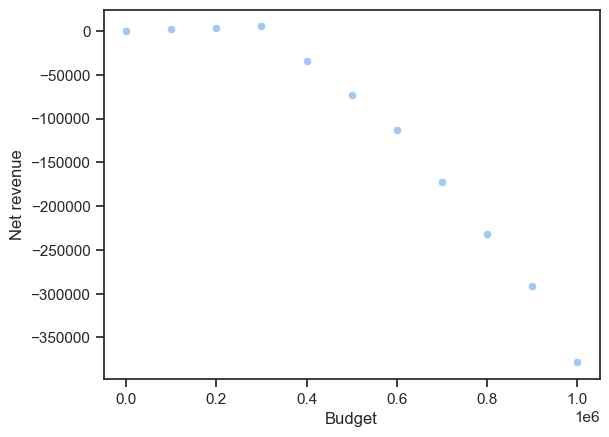

In [59]:
# Plot the revenue as a function of the budget
ax = sns.scatterplot(x = budgets,y = net_revenue)
ax.set_xlabel("Budget")
ax.set_ylabel("Net revenue")

### Q5.2 Is there any concern you would like to share with Ben?

*Insert your answer here:*

The projections for net revenue are concerning. If each click is expected to generate £4, then the ad campaign would not be profitable with Ben's model (diversified keywords). This is because of the CPC for each keyword; the lowest CPC is £3.93 and the highest is £31.12. Under the diversified model, the 7p net revenues from 'retail UK' are eaten by the costs of the other keywords, making the netrevenue of the ad campaign a loss.

Even if the entire budget is spent on 'retail UK', the NetRevenue per click would still be 7p; at 155365 clicks the NetRevenue would still be ~£1000 thus leading to a 0.11% profit margin from ad campaign generated revenue. Therefore, unless the average revenue per click significantly increases from £4, then the ad campaign may not be a worhwhile investment in the short term. 


# Q6. The Optimal Budget (20 pt)

Ben has an idea: *May be we can use linear programming to find the optimal budget to maximize our net revenue!* Concretely, Ben's suggestion is write down an alternative linear programming model, where "budget" is an additional decision variable and the objective is to maximize the total net revenue.

### Q6.1. Formulate the optimal allocation strategy as a linear program

*Hints: Formulas can be written manually and uploaded into a separate .doc file. The model is nearly identical to Q3 except that we have one more variable and a different objective.*

- Decision Variables: keywords, budget (b)
- Constraints: sum of budgets for each keyword = 1000000 i.e. B=10000000
- Objective function: maximise revenue

$$ \max_{NetRev_{B,k} \geq 0} \quad\quad\quad ( \frac{4}{CPC_{r}}\cdot b_{r} + \frac{4}{CPC_{fs}}\cdot b_{fs} + \frac{4}{CPC_{c}}\cdot b_{c} + \frac{4}{CPC_{dl}}\cdot b_{dl} + \frac{4}{CPC_{sd}}\cdot b_{dl})  $$

## Model creation

In [60]:
# The following lines of code import the gurobi package
import gurobipy as gp
from gurobipy import GRB,quicksum

In [61]:
total_budget=1000000

### Q6.2. Create a GUROBI new model "m", named "allocation-budget"



In [62]:
#Insert your code here:
m=gp.Model("allocation-budget")

## Decision variables

### Q6.3. Add decision variables to the model

*Hint: Make sure to also declare a variable "budget"*

In [63]:
#Insert your code here:
allocation = m.addVars(keywords, lb=0, name="allocation")
budget = m.addVar(lb=0, name="budget")

## Constraint

### Q6.4. Add a constraint on the total budget that can be spent


In [64]:
#Insert your code here:
total_budget_constr = m.addConstr(
    budget <= total_budget,
    "total_budget_constr")

allocation_sum_constr = m.addConstr(
    quicksum(allocation[k] for k in keywords) <= budget,
    "allocation_sum_constr"
)


### Q6.5. Add a constraint for diversification



In [65]:
#Insert your code here:
# Add diversification constrain so that each keyword gets at least 1% of the budget
divers_constr = m.addConstrs(
    (allocation[k] >= 0.05*budget for k in keywords),
    name="divers_constr"
)


## Objective

### Q6.6 Specify the linear objective 


In [66]:
#Insert your code here: 
# maximise revenue

m.setObjective(
    quicksum((4.0/CPC[k])*allocation[k] for k in keywords) - budget, 
    GRB.MAXIMIZE
    )


## Solve

Congratulations! You have formulated and implemented the integer program. You can now optimize the net revenue and printout the solution.

In [67]:
# Run the optimization and print the solution vector
def printSolution():
    if m.status == GRB.OPTIMAL:
        print('\nClicks: %g' % m.objVal)
        print('\nAllocation:')
        allocationx = m.getAttr('x', allocation)
        for k in keywords:            
                print('%s %g' % (k, allocationx[k]))
        print("\nBudget: ",budget.x)
    else:
        print('No solution:', m.status)


m.optimize()
printSolution()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7 rows, 6 columns and 17 nonzeros (Max)
Model fingerprint: 0x37338315
Model has 6 linear objective coefficients
Coefficient statistics:
  Matrix range     [5e-02, 1e+00]
  Objective range  [5e-02, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+06, 1e+06]
Presolve removed 7 rows and 6 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -0.0000000e+00   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.02 seconds (0.00 work units)
Optimal objective -0.000000000e+00

Clicks: -0

Allocation:
"retail UK" 0
"free shipping UK" 0
"cardigan" 0
"dua lipa gloves" 0
"spotted dress " 0

Budget:  0.0


### Q6.7. What is the optimal budget level? Which keyword(s) are then selected? How do you interpret this result?

*Insert your answer here:*

The optimal budget is 0 with no keywords selected. The model thus shows that, when the average revenue per click is £4 and there must be some diversification of keywords (min 1% of the budget spent on each keyword), then it is not profitable to run an ad campaign.

### Q6.8. In fact, Ben wants to spend the largest possible budget for which the firm breaks even. Modify the LP accordingly. Is the optimal budget larger or smaller than in Q6.7?

*Insert your answer here:*




In [68]:
# Write your code here
m.remove(divers_constr)

break_even_constr = m.addConstr(
    quicksum((4.0/CPC[k])*allocation[k] for k in keywords) - budget == 0,
    "break_even_constr"
)

m.setObjective(budget, GRB.MAXIMIZE)

In [69]:
m.optimize()
printSolution()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 3 rows, 6 columns and 13 nonzeros (Max)
Model fingerprint: 0xb389cdd5
Model has 1 linear objective coefficients
Coefficient statistics:
  Matrix range     [5e-02, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+06, 1e+06]
Presolve removed 1 rows and 0 columns
Presolve time: 0.01s
Presolved: 2 rows, 6 columns, 12 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.0000000e+06   1.625149e+05   0.000000e+00      0s
       2    1.0000000e+06   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.02 seconds (0.00 work units)
Optimal objective  1.000000000e+06

Clicks: 1e+06

Allocation:
"retail UK" 957412
"free shipping UK" 42588.1
"cardigan" 0
"dua lipa gloves" 0
"spotted dress " 0

Budget:  

# Q7. Practical considerations (15 pt)

Provide qualitative answers to the following questions. There is not a single correct answer, be creative and detailed!

### Q7.1. What aspect of the marketing campaign would it be useful to predict? Why? 

*Insert your answer here:*

The success of a digital marketing campaign depends on the keywords used, when they are used, and their alignment with the brand. Metrics to measure success at this stage would be  click-through-rate (CTR) and the the cost per click (CPC). Once the most relevant keywords are for a client's target segments within a given time frame are decided, one must weigh the cost of the campaign against the expected gains. 

For the expected gains, it would be useful to predict the conversion rate for each keyword. Next it would be useful to predict the average revenue per click for each keyword. Together, these metrics would allow us to compare keywords based on how much consumer interaction and revenue they generate. 

The conversion rate for each key word would be $$ \frac{User Actions_{k}}{clicks_{k}} $$

The revenue per click for each key word would be $$ \frac{Total Revenue_{k}}{clicks_{k}}$$

### Q7.2. In the first part of the workshop, the goal was to maximize the number of clicks. In practice, what objective retailer care about  when acquiring new users? 

*Insert your answer here:*

In practise, the retailer cares about how the ad campaign will improve their bottom line. As such I think the latter models that focused on revenue were better suited to the retailer's needs, however the revenue per click was too generalised to appreciate the value of each keyword and optimise the model fully. 

### Q7.3.  In practice, you might have very limited data on each keyword, and the popular keywords are constantly changing due to various trends. Why is this an issue? How would you modify your strategy to cope with this issue?

*Insert your answer here:*

Limited historical data and rapidly changing keyword popularity create major issues for our metrics. This would make out estimates of CPC, CTR and conversion rates highly uncertain; as such, optimisation results would be unstable and potentially misleading. 

Further, models calibrated on past data would become obsolete when consumer interests shift due to seasonality, trends etc. This would lead to poor budget allocation decisions.

A strategy to mitigate this should combine learning with robustness. I would impose diversification/minimum-spend cdonstraints to reduce overreliance on a keyword. I would then adopt an adaptive approach to the decision optimisation; I would start with conservative allocation and conduct A/B testing, then dynamically reallocate budget toward keywrods that perform well in real time.

### Q7.4. Retailers often post ads on several online exchanges, simultaneously. The same user might see your ad several times (across platforms and keywords) before she decides to click. Is this an issue? Why?

Yes this is an issue. If impressions from different ads are all lead to the same viewers within one timeframe, and are responsible for the same click, then this both reduces CTR. Therefore, each ad would generate less user activity, and subsequently revenue, for the same retailer. As such, the CPC would increase for each keyword and the net revenue from the ad campaign would be low if profitable at all. 

An improved strategy would be for the different ads make impressions on different consumers, at different times, and are responsible for mutually exclusive clicks. This would maximise the breath of audience, increase the CTR and decrease CPC. With all else being equal, this strategy should also generate greater consumer activity which translates to added revenue from the ad campaign.

# Executive Summary Report (20 pts)

Write a 1 pager report summarizing your findings (11 pt font, 1 inch margin, pdf/doc format). This report should take the form of an executive summary that combines elements from your analysis and business recommendations. You can also suggest additional analysis that should be conducted to augment the current allocation model. Think about providing just enough details to a stakeholder that does not have a background in optimization, but that needs data to support decision making. Supporting evidence can be provided in the appendix or by referencing the questions of the workshop. The report will be evaluated along 3 dimensions: clarity, scientific validity, and practical relevance.

# Q8. Piecewise Linear CPC Models (Difficult, Optional, 5 pt Bonus)

You find the current linear CPC model quite unrealistic. According to this model, the cost grows linearly in the desired number of clicks. Your intuition is that the CPC cost is a non-linear function of the budget. *Getting 1M clicks is relatively more expensive than getting a thousand clicks!*

The following heatmap plots the CPC per keyword and per budget level:

<img src="CPC.png" width="800">

### Q8.1. Does the heatmap support your intuition? What phenomenon explains the variation of the CPC?

*Insert your answer here:*


Consequently, we will approximate the CPC model using a **piecewise linear function** instead of a **linear model**. The parameters of the piecewise model were estimated on data and described below. 

In [70]:
# The following dictionary contains the linear slopes in each budget segment, for each keyword

pieces_list = ['piece A','piece B']
PiecewiseCPC = {('"retail UK"', 'piece A'): [4.1, 0, 20000],
                 ('"retail UK"', 'piece B'): [1e+100, 20000, 1000000],
                 ('"free shipping UK"', 'piece A'): [3.0, 0, 20000],
                 ('"free shipping UK"', 'piece B'): [6.9, 20000, 1000000],
                 ('"cardigan"', 'piece A'): [1.5, 0, 20000],
                 ('"cardigan"', 'piece B'): [41.1, 20000, 1000000],
                 ('"dua lipa gloves"', 'piece A'): [2.5, 0, 20000],
                 ('"dua lipa gloves"', 'piece B'): [233.6, 20000, 1000000],
                 ('"spotted dress "', 'piece A'): [4.7, 0, 20000],
                 ('"spotted dress "', 'piece B'): [10.4, 20000, 1000000]}

*How do you interpret the PiecewiseCPC dictionary?*
- The CPC model has two linear pieces.
- For example for "cardigan", the cost increases initially by £1.5 per click, between 0 and 20,000 clicks. Next, the cost increases by £41.1 per click, between 20,000 and 1,000,000 clicks. 

*Why is the slope very large for the keyword "retail UK" on piece B*?
- There is no historical data point to inform the slope above 20,000 clicks for the keyword "retail UK"
- Instead of extrapolating what the slope would be, we put a large conservative value, so that our model won't pick a budget larger than that corresponding to 20,000 clicks.
- *When you don't know, you should not guess!*

### Q8.2. Develop a linear program that optimizes the allocation of £1M under piecewise linear CPC models. 

*Hint: Create one extra decision variable for each keyword and piece of the CPC function. For example, the "retail UK" allocation variable can be decomposed as  $x_{retailUK}  = y_{retailUK,A} + y_{retailUK,B} $ with two new decision variables $y_{retailUK,A},y_{retailUK,B}$, where $y_{retailUK,A}$ is upper bounded by 20,000.*

In [71]:
# Write your code here


### Q8.3. Which keywords are selected in the optimal allocation strategy? Compare to Q3.

*Insert your answer here:*

### About the piecewise linear model...

How would you estimate the piecewise linear CPC model from historical data? The code is provided below. 
1. Slice the data set into three budget segments: [0,20000],  [20000,1000000], 
- Within each budget segment, fit a linear regression model to obtain the "slope" of the CPC function
- In this case, you need to use an intercept in the model.



In [72]:
import numpy as np
from sklearn.linear_model import LinearRegression

keywords = df.keyword.drop_duplicates().tolist()
pCPC = {}
pieces = {'piece A': [0,20000], 'piece B': [20000,1000000]}

for k in keywords:
    for p in pieces.keys():
        df_k = df[(df["keyword"]==k) &(pieces[p][0]<=df['budget'])&(pieces[p][1]>=df['budget'])]
        if df_k.shape[0]> 0:
            X = df_k.budget.values.reshape((df_k.shape[0],1))
            y = df_k.clicks.values 
            reg = LinearRegression(fit_intercept = True).fit(X, y)
            pCPC[k,p] = [1.0/reg.coef_[0]] + pieces[p]
            print("\n CPC of keyword "+k+ " and "+p+" is: £",1/reg.coef_[0]," per click")
            print("The R2 for the linear regression is:",reg.score(X,y))            
        else:
            pCPC[k,p] = [GRB.INFINITY] + pieces[p]            


 CPC of keyword "retail UK" and piece A is: £ 4.108797336465324  per click
The R2 for the linear regression is: 0.8459055955015281

 CPC of keyword "free shipping UK" and piece A is: £ 3.040688826141066  per click
The R2 for the linear regression is: 0.8084685625178041

 CPC of keyword "free shipping UK" and piece B is: £ 6.943809878345913  per click
The R2 for the linear regression is: 0.9985379109774118

 CPC of keyword "cardigan" and piece A is: £ 1.5581151104525688  per click
The R2 for the linear regression is: 0.4575230748616187

 CPC of keyword "cardigan" and piece B is: £ 41.15743647805942  per click
The R2 for the linear regression is: 0.8732355509244926

 CPC of keyword "dua lipa gloves" and piece A is: £ 2.4958611695155186  per click
The R2 for the linear regression is: 0.9998388558619081

 CPC of keyword "dua lipa gloves" and piece B is: £ 233.57280649945116  per click
The R2 for the linear regression is: 0.21762698141762626

 CPC of keyword "spotted dress " and piece A is